In [1]:
!pip install scikit-learn-extra

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

In [3]:
from google.colab import files

uploaded = files.upload()


Saving Mall_Customers.csv to Mall_Customers.csv


In [4]:
df = pd.read_csv("Mall_Customers.csv")

In [5]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.shape

(200, 5)

In [7]:
X = df[
    [
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]


In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)



In [9]:
kmedoids = KMedoids(
    n_clusters=5,
    metric="euclidean",
    random_state=42
)


clusters = kmedoids.fit_predict(X_scaled)

In [10]:

df["Cluster"] = clusters


print("\nClustered Data:")
print(df.head())


Clustered Data:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        1  
1        0  
2        1  
3        0  
4        1  


In [11]:
print("\nMedoid Points:")
print(kmedoids.cluster_centers_)



Medoid Points:
[[-1.3573049   0.88513158]
 [-0.78476346 -0.3183368 ]
 [ 0.70384427  1.27334719]
 [-0.02137488 -0.04658587]
 [ 1.04736914 -1.36651894]]


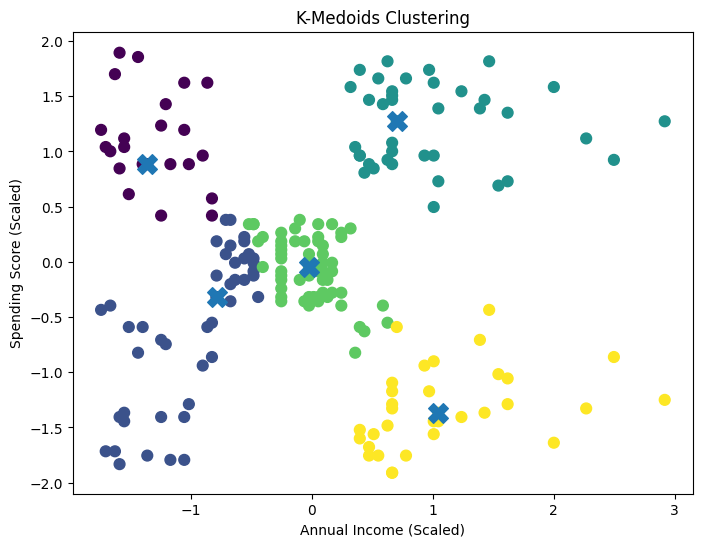

In [12]:
plt.figure(figsize=(8,6))


plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters,
    s=60
)


plt.scatter(
    kmedoids.cluster_centers_[:,0],
    kmedoids.cluster_centers_[:,1],
    marker="X",
    s=200
)


plt.xlabel("Annual Income (Scaled)")

plt.ylabel("Spending Score (Scaled)")


plt.title("K-Medoids Clustering")


plt.show()


In [13]:

silhouette = silhouette_score(
    X_scaled,
    clusters
)


print(
    "\nK-Medoids Silhouette Score:",
    silhouette
)



K-Medoids Silhouette Score: 0.44764405993975875


In [14]:
print("\nCluster Counts:")
print(df["Cluster"].value_counts())


Cluster Counts:
Cluster
3    60
1    45
2    39
4    33
0    23
Name: count, dtype: int64
